## Food Image Classification

JNTU No: 23341A05G8
Name: Mudidhana Suvarna Likitha
Model: MobileNetV3

## 1. Problem Statement

The objective of this project is to identify common food categories from photographs using a pre-trained MobileNetV3 model.

The system accepts a food photograph as input, preprocesses the image, passes it through the pre-trained model, performs inference, and produces the predicted class along with its confidence score.

No custom dataset is used for training and the model is not trained or fine-tuned during this project.

## 2. Objective

The objectives of this project are:

- To understand the concept of pre-trained deep learning models.
- To use a pre-trained MobileNetV3 model for image classification.
- To load and preprocess a food image.
- To perform inference using the pre-trained model.
- To process the model output and obtain class probabilities.
- To display the top predicted food-related categories.
- To demonstrate the system using at least three different test images.

## 3. Introduction to MobileNetV3

MobileNetV3 is a lightweight convolutional neural network architecture designed for efficient computer vision tasks.

It is suitable for applications where computational efficiency is important.

For this project, MobileNetV3-Large is used with pre-trained ImageNet-1K weights.

The model is already trained before this project. Therefore, this project performs inference only and does not train the model on a custom food dataset.

## 4. Why MobileNetV3 Was Selected

MobileNetV3 was selected because:

- It is the model assigned for this project.
- It is a lightweight image classification architecture.
- Pre-trained weights are openly available through TorchVision.
- It can perform image classification without training a new model from scratch.
- It is suitable for demonstrating the complete pre-trained model inference workflow.

## 5. Model Information


 Model :-  MobileNetV3-Large 
 Model Type :- Convolutional Neural Network (CNN) 
 Pre-trained Weights :- ImageNet-1K 
 Number of Classes :-  1000 
 Input :- RGB image 
 Model Input Size :- 224 × 224 pixels after preprocessing 
 Output :- Scores for 1000 ImageNet classes 
 Project Method :- Inference only 
 Custom Training :- Not performed
 Custom Food Dataset :- Not used 

## 6. Working Principle

The complete workflow of the project is:

Input Food Image
        ↓
Image Loading
        ↓
Pre-processing
        ↓
Pre-trained MobileNetV3
        ↓
Inference
        ↓
Class Scores
        ↓
Softmax Probabilities
        ↓
Top-5 Predictions
        ↓
Final Classification Output

## 7. Libraries and Requirements

The following Python libraries are used:

PyTorch – deep learning framework
TorchVision – pre-trained MobileNetV3 model and preprocessing
Pillow – image loading and processing
Requests – downloading images from URLs
IPython – displaying images in Jupyter Notebook

In [57]:
!pip install torch torchvision pillow requests

In [59]:
import torch

from torchvision.models import (
    mobilenet_v3_large,
    MobileNet_V3_Large_Weights
)

from PIL import Image
import requests
from io import BytesIO

from IPython.display import display


## 8. Loading the Pre-trained MobileNetV3 Model

The model is loaded with pre-trained ImageNet-1K weights.

The `weights` parameter loads the learned parameters that were obtained during the original training of the model.

The model is set to evaluation mode because this project performs inference and does not perform training.

In [62]:
weights = MobileNet_V3_Large_Weights.DEFAULT

model = mobilenet_v3_large(weights=weights)

model.eval()

print("MobileNetV3-Large pretrained model loaded successfully!")

MobileNetV3-Large pretrained model loaded successfully!


## 9. Loading ImageNet Class Labels

The pre-trained model was originally trained for ImageNet image classification.

The model produces scores for 1000 ImageNet categories.

The class names are obtained directly from the metadata associated with the pre-trained weights.

In [65]:
categories = weights.meta["categories"]

print("Number of ImageNet classes:", len(categories))
# print("\nFirst 10 classes:")

# for i in range(10):
#     print(i, categories[i])

Number of ImageNet classes: 1000


## 10. Input Image

The system can accept a food photograph from an image URL.

The image is downloaded and converted into RGB format before preprocessing.

In [68]:
image_url = "https://chefstandards.com/wp-content/uploads/2025/06/Slicing-Through-The-17-Best-Pizza-Types.jpg"

response = requests.get(image_url, timeout=30)

print("Status code:", response.status_code)

image = Image.open(BytesIO(response.content)).convert("RGB")

print("Image loaded successfully!")
print("Image size:", image.size)

Status code: 200
Image loaded successfully!
Image size: (1200, 624)


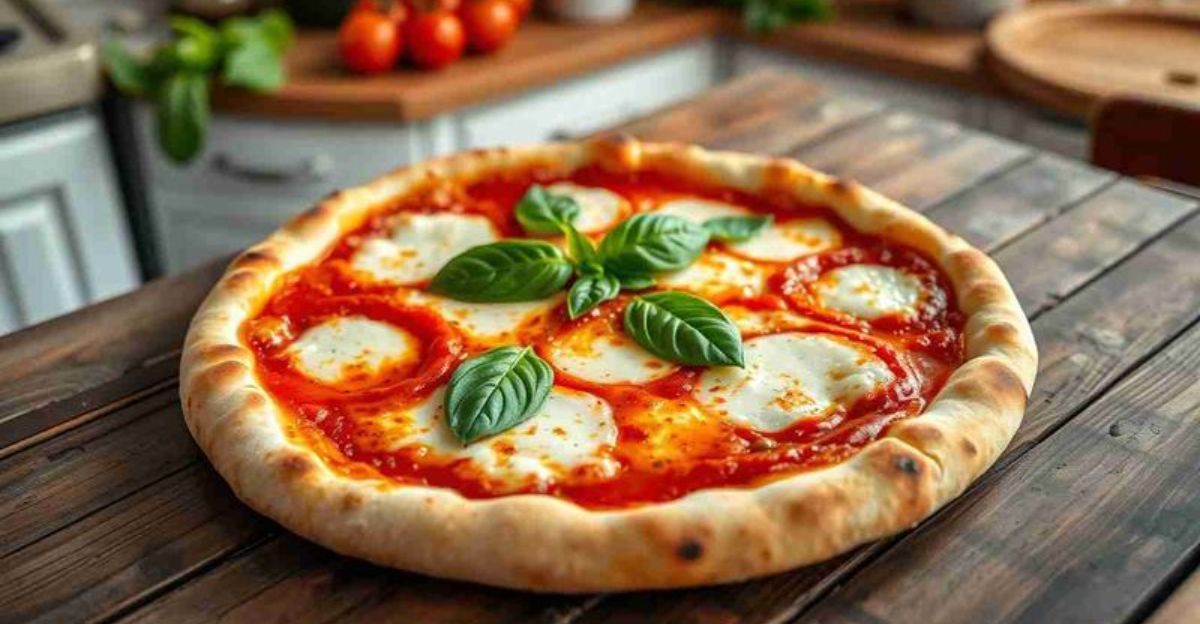

In [69]:
display(image)

## 11. Image Pre-processing

The input image must be converted into the format expected by the pre-trained MobileNetV3 model.

The preprocessing transformation provided with the model weights is used.

It performs the required resizing, center cropping, conversion to tensor, and normalization.

The final image is represented as a tensor suitable for the model.

In [73]:
# Get the preprocessing transformation associated with the pretrained weights
preprocess = weights.transforms()

# Apply preprocessing
input_image = preprocess(image)

# Add batch dimension
input_batch = input_image.unsqueeze(0)

print("Image preprocessed successfully!")
print("Input shape:", input_batch.shape)

Image preprocessed successfully!
Input shape: torch.Size([1, 3, 224, 224])


## 12. Model Inference

Inference means using the already trained model to make a prediction on a new input image.

No training or gradient calculation is performed during inference.

In [76]:
# Perform inference without calculating gradients
with torch.no_grad():
    output = model(input_batch)

print("Prediction completed!")
print("Output shape:", output.shape)

Prediction completed!
Output shape: torch.Size([1, 1000])


## 13. Output Processing

The raw model outputs are converted into probabilities using the Softmax function.

The probabilities indicate how strongly the model associates the input image with each ImageNet class.

The top five classes are then selected based on their probabilities.

In [79]:
# Convert model scores into probabilities
probabilities = torch.nn.functional.softmax(output[0], dim=0)

print("Prediction probabilities generated.")
print("Total probability:", probabilities.sum().item())

Prediction probabilities generated.
Total probability: 0.9999997019767761


In [81]:
# Get the top 5 predictions
top5_prob, top5_indices = torch.topk(probabilities, 5)

print("Top 5 Predictions:\n")

for probability, index in zip(top5_prob, top5_indices):
    print(
        f"{categories[index]} : "
        f"{probability.item() * 100:.2f}%"
    )

Top 5 Predictions:

pizza : 77.83%
potpie : 0.29%
zucchini : 0.26%
loggerhead : 0.12%
frying pan : 0.12%


## 14. Final Prediction

The class with the highest probability is considered the model's top prediction.

The confidence value shown below represents the model's probability for that predicted ImageNet class.

In [84]:
# Get the highest probability prediction
predicted_index = torch.argmax(probabilities).item()

predicted_class = categories[predicted_index]

predicted_probability = (
    probabilities[predicted_index].item() * 100
)

print("Predicted Food Category:", predicted_class)
print("Confidence:", f"{predicted_probability:.2f}%")

Predicted Food Category: pizza
Confidence: 77.83%


## Note
MobileNetV3 with ImageNet-1K weights is a general image classifier, not a food-specific classifier. Therefore, only food-related ImageNet classes should be interpreted as food predictions. Other ImageNet classes may be produced for images that the model does not recognize as a food category.

## 15. Reusable Food Prediction Function

The following function combines image loading, preprocessing, inference, probability calculation and top-5 prediction into one reusable workflow.

It supports both:
- Local image files
- Image URLs

In [90]:
def predict_food(image_source):
    
    # ---------------------------------
    # 1. Load image
    # ---------------------------------
    if image_source.startswith("http://") or image_source.startswith("https://"):
        
        response = requests.get(image_source, timeout=30)
        
        if response.status_code != 200:
            print("Could not download the image.")
            return
        
        image = Image.open(
            BytesIO(response.content)
        ).convert("RGB")
        
    else:
        image = Image.open(image_source).convert("RGB")
    
    # ---------------------------------
    # 2. Display image
    # ---------------------------------
    display(image)
    
    # ---------------------------------
    # 3. Preprocess image
    # ---------------------------------
    input_image = preprocess(image)
    input_batch = input_image.unsqueeze(0)
    
    # ---------------------------------
    # 4. Model inference
    # ---------------------------------
    with torch.no_grad():
        output = model(input_batch)
    
    # ---------------------------------
    # 5. Convert scores to probabilities
    # ---------------------------------
    probabilities = torch.nn.functional.softmax(
        output[0], dim=0
    )
    
    # ---------------------------------
    # 6. Get Top-5 predictions
    # ---------------------------------
    top5_prob, top5_indices = torch.topk(
        probabilities, 5
    )
    
    # ---------------------------------
    # 7. Display result
    # ---------------------------------
    predicted_index = top5_indices[0].item()
    predicted_class = categories[predicted_index]
    predicted_probability = top5_prob[0].item() * 100
    
    print("\n" + "=" * 45)
    print("FINAL PREDICTION")
    print("=" * 45)
    
    print("Predicted Class:", predicted_class)
    print("Confidence:", f"{predicted_probability:.2f}%")
    
    print("\nTop 5 Predictions:")
    
    for probability, index in zip(
        top5_prob, top5_indices
    ):
        print(
            f"{categories[index]} : "
            f"{probability.item() * 100:.2f}%"
        )

## 16. Test Case 1

The first test case uses a food photograph as input.

The system displays the image and generates the top five ImageNet predictions.

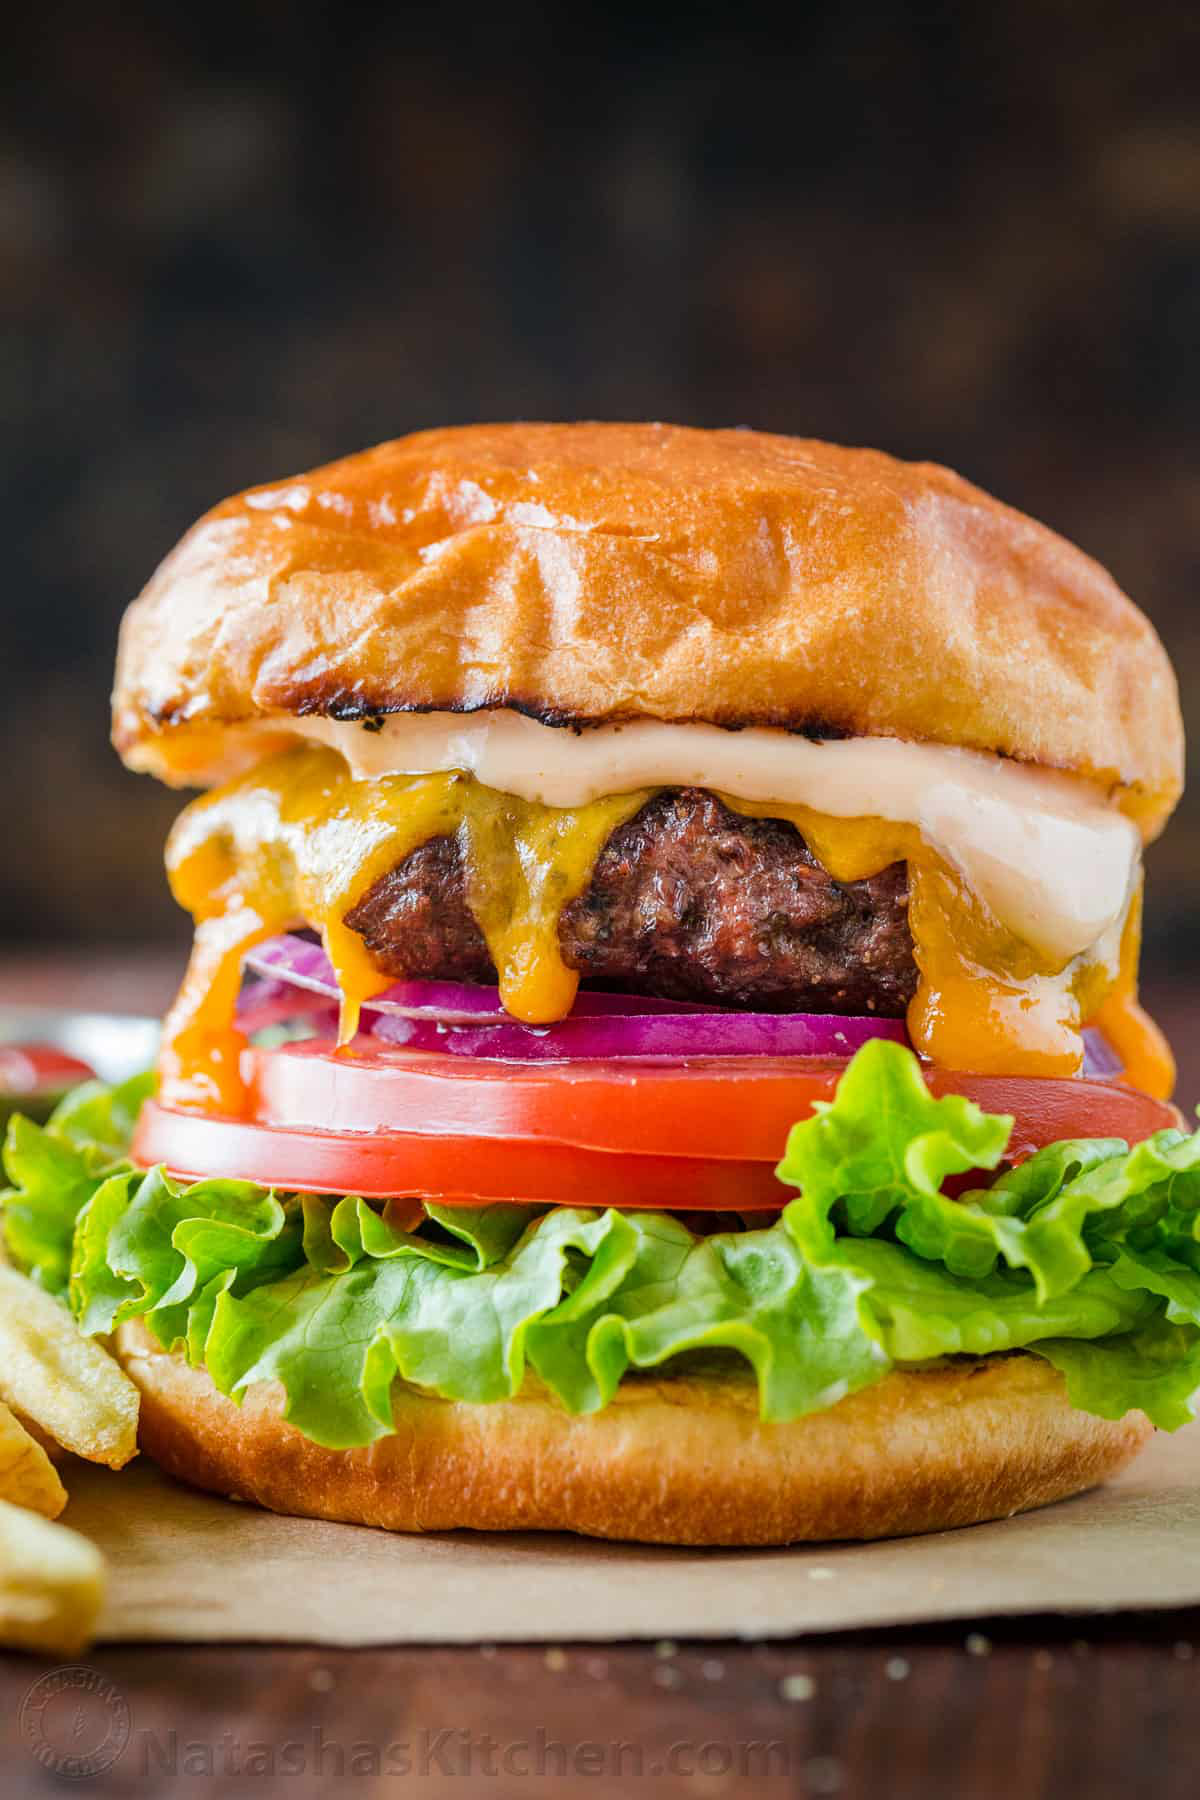


FINAL PREDICTION
Predicted Class: cheeseburger
Confidence: 61.85%

Top 5 Predictions:
cheeseburger : 61.85%
meat loaf : 0.63%
plate : 0.28%
guacamole : 0.23%
hotdog : 0.22%


In [103]:
predict_food("https://natashaskitchen.com/wp-content/uploads/2019/04/Best-Burger-4.jpg")

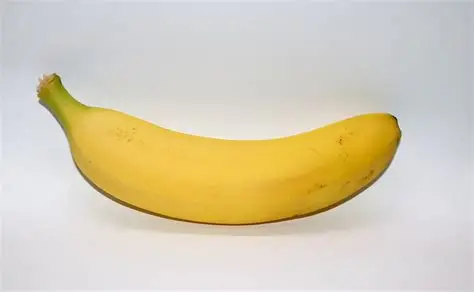


FINAL PREDICTION
Predicted Class: banana
Confidence: 86.84%

Top 5 Predictions:
banana : 86.84%
spaghetti squash : 0.39%
slug : 0.32%
butternut squash : 0.18%
hook : 0.10%


In [111]:
predict_food("https://tse3.mm.bing.net/th/id/OIP.Z-FNmIq1kGTQHfrp1vNczAHaEk?r=0&rs=1&pid=ImgDetMain&o=7&rm=3")

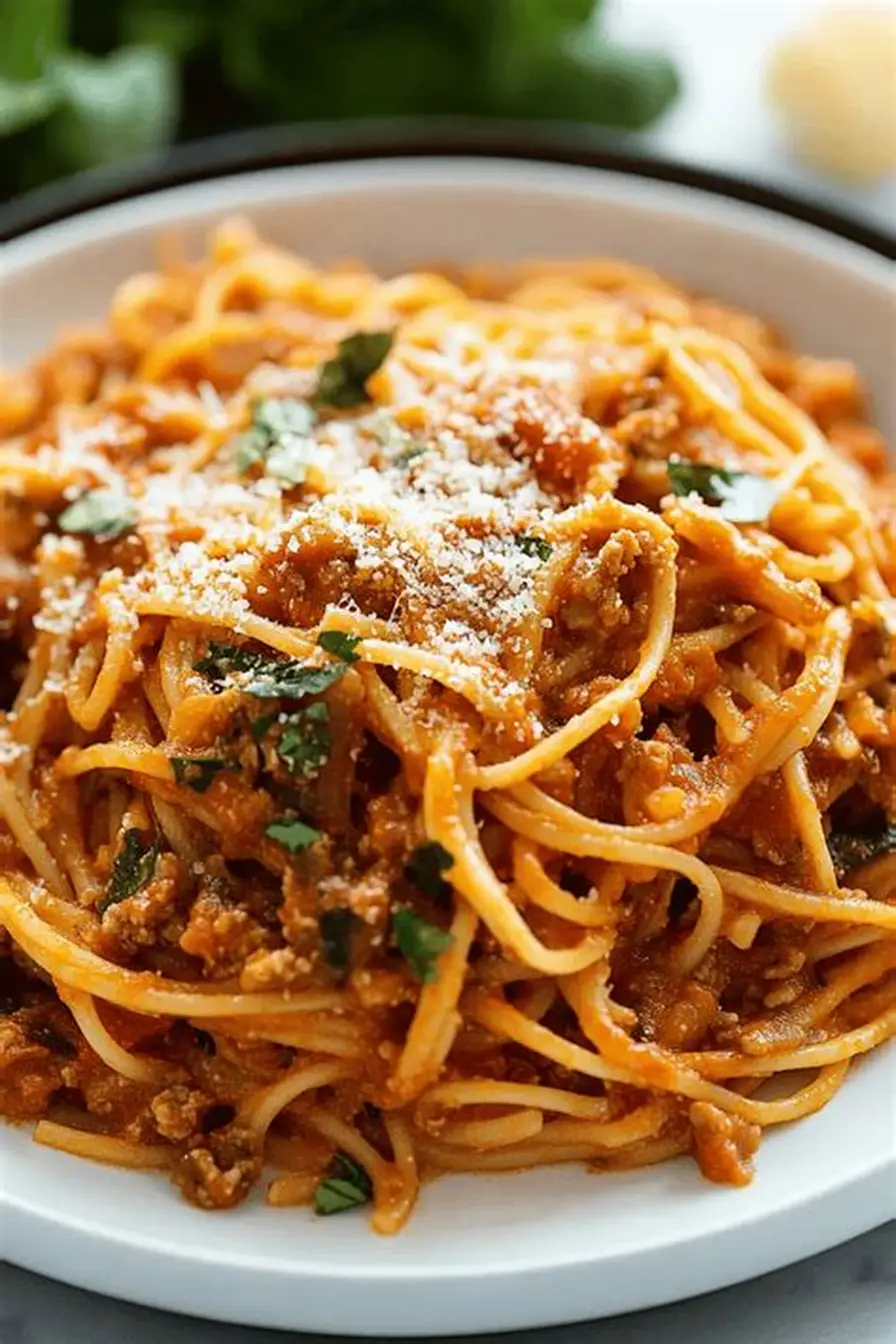


FINAL PREDICTION
Predicted Class: carbonara
Confidence: 82.47%

Top 5 Predictions:
carbonara : 82.47%
plate : 1.10%
meat loaf : 0.63%
coral fungus : 0.49%
spaghetti squash : 0.45%


In [130]:
predict_food("https://tse1.mm.bing.net/th/id/OIP.rVBQQ8QiPeOqE1XgB36zUQHaLH?r=0&w=896&h=1344&rs=1&pid=ImgDetMain&o=7&rm=3")

The model was tested using three different food images.

The predicted class and confidence score were recorded for each test case.

| Test Case | Input   | Predicted Class | Confidence |
|-----------|---------|-----------------|------------|
| 1         | Burger  | cheeseburger    | 61.85%     |
| 2         | Banana  | banana          | 86.84%     |
| 3         | Spagetti| carbonara       | 81.54%     |

The results show that the pretrained MobileNetV3 model can perform image classification directly using its learned ImageNet representations without additional training.

### Model Source

The MobileNetV3-Large model and its pretrained ImageNet weights are obtained through the PyTorch TorchVision library.

Model:
 MobileNetV3-Large

Weights:
 MobileNet_V3_Large_Weights.DEFAULT
(ImageNet-1K V2)

Source:
 PyTorch TorchVision

The TorchVision project is distributed under the BSD license. The pretrained models can have terms associated with the datasets used to train them, so the relevant model/dataset terms should be checked before redistribution or commercial use.

## Limitations:

1. The MobileNetV3 model used here is a general ImageNet image classifier rather than a food-specific classifier.

2. The model can recognize only the categories represented in its original ImageNet output classes.

3. Some regional or visually similar foods may not be identified correctly.

4. A high confidence score does not guarantee that the prediction is correct.

5. No custom food dataset or fine-tuning is performed in this project.

6. Therefore, the system should be considered a demonstration of pretrained image classification rather than a specialized food-recognition system.

## Future Scope:

- Using a food-specific pretrained model.
- Supporting a larger number of food categories.
- Adding a webcam or live camera input.
- Developing a simple web-based interface.
- Improving recognition of regional foods.
- Connecting the identified food with nutritional information.
- Adapting the model for a specialized food dataset in a future transfer-learning project.

## Conclusion

This project demonstrated the use of a pre-trained MobileNetV3-Large model for image classification.

A food photograph was taken as input, preprocessed using the transformations associated with the pretrained weights, and passed through the model for inference.

The model output was converted into probabilities and the top predicted classes were displayed.

The project demonstrates how a pre-trained deep learning model can be used for a practical image-classification application without training a new deep-learning model from scratch.

The main limitation is that the selected MobileNetV3 weights were trained for general ImageNet classification rather than specifically for food recognition.